In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kenjee/z-by-hp-unlocked-challenge-3-signal-processing")

print("Path to dataset files:", path)

Mounting files to /kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing...
Path to dataset files: /kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing


In [2]:
!pip install tensorflow
!pip install tensorflow-gpu
!pip install tensorflow-io matplotlib

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
import os
from matplotlib import pyplot as plt
import tensorflow as tf 
import tensorflow_io as tfio

2026-05-26 12:43:28.787962: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779799409.018289      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779799409.089849      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779799409.609466      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779799409.609504      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779799409.609507      57 computation_placer.cc:177] computation placer alr

In [26]:
CAPUCHIN_FILE = '/kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips/XC3776-3.wav'

NOT_CAPUCHIN_FILE = '/kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Not_Capuchinbird_Clips/afternoon-birds-song-in-forest-0.wav'


In [51]:
import tensorflow as tf
import librosa

def load_wav_16k_mono(filename):

    file_path = filename.numpy().decode("utf-8")

    wav, sample_rate = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    return wav.astype(np.float32)

In [32]:
CAPUCHIN_FILE

'/kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips/XC3776-3.wav'

In [33]:
wave = load_wav_16k_mono(CAPUCHIN_FILE)
nwave = load_wav_16k_mono(NOT_CAPUCHIN_FILE)

In [30]:
import os

print(os.path.exists(CAPUCHIN_FILE))
print(os.path.exists(NOT_CAPUCHIN_FILE))

True
True


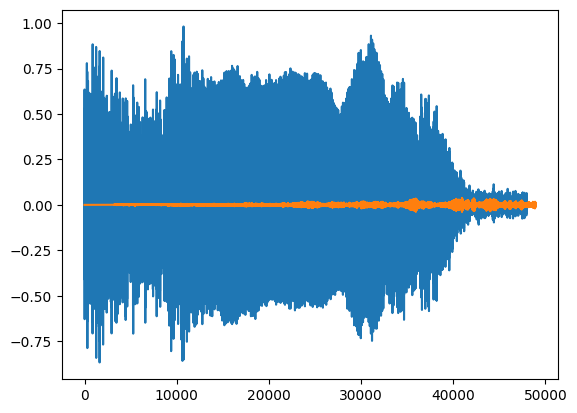

In [34]:
plt.plot(wave)
plt.plot(nwave)
plt.show()

In [35]:
POS = '/kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Capuchinbird_Clips'
NEG = '/kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing/Parsed_Not_Capuchinbird_Clips'

In [37]:
pos = tf.data.Dataset.list_files(os.path.join(POS, '*.wav'))
neg = tf.data.Dataset.list_files(os.path.join(NEG, '*.wav'))

In [38]:
positives = tf.data.Dataset.zip(
    (
        pos,
        tf.data.Dataset.from_tensor_slices(
            tf.ones(len(list(pos.as_numpy_iterator())))
        )
    )
)

negatives = tf.data.Dataset.zip(
    (
        neg,
        tf.data.Dataset.from_tensor_slices(
            tf.zeros(len(list(neg.as_numpy_iterator())))
        )
    )
)

data = positives.concatenate(negatives)

In [39]:
lengths = []

for file in os.listdir(POS):
    file_path = os.path.join(POS, file)

    tensor_wave = load_wav_16k_mono(file_path)

    lengths.append(len(tensor_wave))

In [42]:
import numpy as np

In [43]:
print("Mean Length:", np.mean(lengths))
print("Min Length:", np.min(lengths))
print("Max Length:", np.max(lengths))

Mean Length: 54156.6866359447
Min Length: 32000
Max Length: 80000


In [68]:
def preprocess(file_path, label):

    def load_audio(path):

        path = path.numpy()

        if isinstance(path, bytes):
            path = path.decode("utf-8")

        elif isinstance(path, np.ndarray):
            path = path.item().decode("utf-8")

        wav, sr = librosa.load(
            path,
            sr=16000,
            mono=True
        )

        wav = wav.astype(np.float32)

        # Force fixed length BEFORE returning
        if len(wav) > 48000:
            wav = wav[:48000]
        else:
            wav = np.pad(
                wav,
                (0, 48000 - len(wav))
            )

        return wav

    wav = tf.py_function(
        func=load_audio,
        inp=[file_path],
        Tout=tf.float32
    )

    # VERY IMPORTANT
    wav.set_shape([48000])

    spectrogram = tf.signal.stft(
        wav,
        frame_length=320,
        frame_step=32
    )

    spectrogram = tf.abs(spectrogram)

    spectrogram = tf.expand_dims(
        spectrogram,
        axis=-1
    )

    # VERY IMPORTANT
    spectrogram.set_shape([1491, 257, 1])

    label = tf.cast(label, tf.float32)

    return spectrogram, label

In [46]:
!pip install librosa soundfile --quiet

In [47]:
import os
import numpy as np
import pandas as pd
import librosa
import tensorflow as tf
from matplotlib import pyplot as plt

In [48]:
BASE_PATH = "/kaggle/input/datasets/kenjee/z-by-hp-unlocked-challenge-3-signal-processing"

In [69]:
data = positives.concatenate(negatives)

data = data.map(
    preprocess,
    num_parallel_calls=tf.data.AUTOTUNE
)

data = data.cache()

data = data.shuffle(1000)

data = data.batch(16)

data = data.prefetch(tf.data.AUTOTUNE)

In [70]:
train = data.take(36)
test = data.skip(36).take(15)

In [71]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    Dense,
    Flatten,
    MaxPooling2D,
    Dropout
)

model = Sequential([

    Input(shape=(1491,257,1)),

    Conv2D(16, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(),

    Flatten(),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(1, activation='sigmoid')

])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 1489, 255, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 744, 127, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 742, 125, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 371, 62, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 369, 60, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 184, 30, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 353280)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    90,439,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90,463,489 (345.09 MB)

 Trainable params: 90,463,489 (345.09 MB)

 Non-trainable params: 0 (0.00 B)

In [72]:
model.compile(
    optimizer='adam',
    loss='BinaryCrossentropy',
    metrics=['accuracy']
)

In [73]:
history = model.fit(
    train,
    epochs=4,
    validation_data=test
)

Epoch 1/4


I0000 00:00:1779802576.987263     131 cuda_dnn.cc:529] Loaded cuDNN version 91002


 1/36 ━━━━━━━━━━━━━━━━━━━━ 9:14 16s/step - accuracy: 0.3125 - loss: 0.6909

I0000 00:00:1779802586.206017     131 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step - accuracy: 0.8427 - loss: 0.7371 - val_accuracy: 0.9615 - val_loss: 0.0846
Epoch 2/4
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9825 - loss: 0.0862 - val_accuracy: 0.9872 - val_loss: 0.0843
Epoch 3/4
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 119ms/step - accuracy: 0.9835 - loss: 0.0689 - val_accuracy: 0.9957 - val_loss: 0.0120
Epoch 4/4
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 116ms/step - accuracy: 0.9895 - loss: 0.0180 - val_accuracy: 1.0000 - val_loss: 0.0029


In [58]:
samples = data.as_numpy_iterator()

example_spectrogram, example_label = samples.next()

print(example_spectrogram.shape)

(16, 1491, 257, 1)


In [74]:
model.save('/kaggle/working/capuchin_classifier.keras')

In [75]:
FOREST_PATH = os.path.join(BASE_PATH, 'Forest Recordings')

In [ ]:
forest_files = os.listdir(FOREST_PATH)

results = {}

for file in forest_files:

    file_path = os.path.join(
        FOREST_PATH,
        file
    )

    # Load audio directly
    wav, sr = librosa.load(
        file_path,
        sr=16000,
        mono=True
    )

    # Pad or trim
    if len(wav) > 48000:
        wav = wav[:48000]
    else:
        wav = np.pad(
            wav,
            (0, 48000 - len(wav))
        )

    # Spectrogram
    spectrogram = tf.signal.stft(
        wav,
        frame_length=320,
        frame_step=32
    )

    spectrogram = tf.abs(spectrogram)

    spectrogram = tf.expand_dims(
        spectrogram,
        axis=-1
    )

    spectrogram = tf.expand_dims(
        spectrogram,
        axis=0
    )

    prediction = model.predict(
        spectrogram,
        verbose=0
    )

    results[file] = float(prediction[0][0])

print(results)

In [79]:
import pandas as pd

# Convert dictionary to dataframe
results_df = pd.DataFrame(
    list(results.items()),
    columns=['file_name', 'prediction']
)

# Save CSV
results_df.to_csv(
    '/kaggle/working/results.csv',
    index=False
)

print(results_df.head())

          file_name    prediction
0  recording_76.mp3  5.410957e-02
1  recording_62.mp3  5.523356e-20
2  recording_48.mp3  8.099676e-02
3  recording_44.mp3  1.394256e-02
4  recording_45.mp3  5.621728e-03


In [80]:
loss, accuracy = model.evaluate(test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9907 - loss: 0.0158
Test Loss: 0.011170445010066032
Test Accuracy: 0.995726466178894
